In [3]:
import scanpy as sc
import hisemble
import warnings
warnings.filterwarnings("ignore")
sc.settings.verbosity = 0

In [4]:
adata = sc.read_h5ad('../demo_data/mouse_brain.h5ad')
adata

AnnData object with n_obs × n_vars = 13671 × 162398
    obs: 'batch', 'cell_type', 'cell_type_raw', 'test_type'
    var: 'peak', 'n_cells'
    obsm: 'X_lsi', 'X_scBasset', 'X_snap'

In [5]:
hisemble.run_hisemble(
    adata=adata,
    input_keys=['X_lsi', 'X_snap', 'X_scBasset'], # Update these to match the actual representation keys in your adata
    metrics=['cosine', 'gaussian', 'gaussian'],   # Choose distance metrics suited to each base method ('cosine' is recommended for LSI)
    k_neighbors=15,          # Number of nearest neighbors for the KNN graph
    n_iterations=20,         # Number of iterations for the fusion algorithm
    resolution=1.0,          # Leiden clustering resolution. Adjust this value to control cluster granularity (higher value = more clusters)
    key_added='Hisemble_clusters'
)

Building KNN graph for X_lsi using cosine metric...
Building KNN graph for X_snap using gaussian metric...
Building KNN graph for X_scBasset using gaussian metric...
Running Hisemble sparse cross-diffusion...
  - Iteration 1/20...
  - Iteration 2/20...
  - Iteration 3/20...
  - Iteration 4/20...
  - Iteration 5/20...
  - Iteration 6/20...
  - Iteration 7/20...
  - Iteration 8/20...
  - Iteration 9/20...
  - Iteration 10/20...
  - Iteration 11/20...
  - Iteration 12/20...
  - Iteration 13/20...
  - Iteration 14/20...
  - Iteration 15/20...
  - Iteration 16/20...
  - Iteration 17/20...
  - Iteration 18/20...
  - Iteration 19/20...
  - Iteration 20/20...
Running Leiden clustering with resolution 1.0...
Finished! Fused graph saved to `.obsp['connectivities']`.
Cluster labels saved to `.obs['Hisemble_clusters']`.


In [6]:
adata

AnnData object with n_obs × n_vars = 13671 × 162398
    obs: 'batch', 'cell_type', 'cell_type_raw', 'test_type', 'Hisemble_clusters'
    var: 'peak', 'n_cells'
    uns: 'neighbors'
    obsm: 'X_lsi', 'X_scBasset', 'X_snap'
    obsp: 'connectivities', 'distances'

In [7]:
sc.tl.umap(adata)

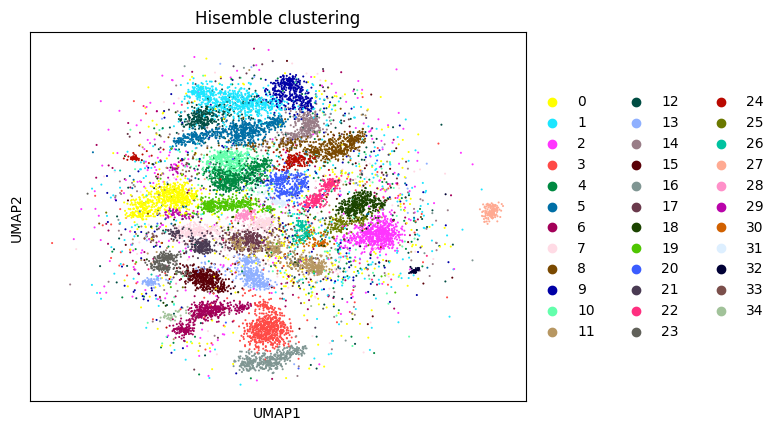

In [8]:
sc.pl.umap(
    adata, 
    color=['Hisemble_clusters'],
    title='Hisemble clustering'
)